In [206]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import DBSCAN
from sklearn.cluster import OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.graph_objects as go

In [207]:
custom = pd.read_csv('/Users/aleksrzesny/Desktop/LUISS Y1/Python and R/labds/labds/DataScience/project/customer_features_with_clusters.csv')
master = pd.read_csv('/Users/aleksrzesny/Desktop/LUISS Y1/Python and R/labds/labds/DataScience/project/master_transactions.csv')

# Feature engineering and preprocessing

In [208]:
custom = custom.drop('cluster', axis=1)

In [209]:
# Converting Date and calculating Recency (Days since last purchase relative to Feb 28, 2025)
master['Date'] = pd.to_datetime(master['Date'], format='%d%b%Y', errors='coerce')

In [210]:
# Reference date for Recency (Feb 28, 2025)
ref_date = master['Date'].max()

# Recency: How many days ago was their last transaction
recency_df = master.groupby('customer_id')['Date'].max().reset_index()
recency_df['recency_days'] = (ref_date - recency_df['Date']).dt.days

# Pulling demographics from master 
demographics = master[['customer_id', 'Gender', 'province']].drop_duplicates('customer_id')

In [211]:
# MERGING INTO FINAL CLUSTERING TABLE
df_final = custom.merge(recency_df[['customer_id', 'recency_days']], on='customer_id', how='left')
df_final = df_final.merge(demographics, on='customer_id', how='left')

In [212]:
# Handle missing recency: if a customer is in 'custom' but not 'master', 
# they haven't purchased in the timeframe. Set to a high value, in this case 600 days
df_final['recency_days'] = df_final['recency_days'].fillna(600)

In [213]:
# PREPROCESSING
# Use standard scaler for numerical features and one-hot encoding for categorical
num_cols = ['age_years', 'net_amount', 'transaction_count', 'return_rate_tx', 
            'nl_open_rate', 'nl_click_rate', 'recency_days']
cat_cols = ['Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Drop any rows where numerical data is missing before scaling
df_final = df_final.dropna(subset=num_cols)

X_scaled = preprocessor.fit_transform(df_final)

# K-means

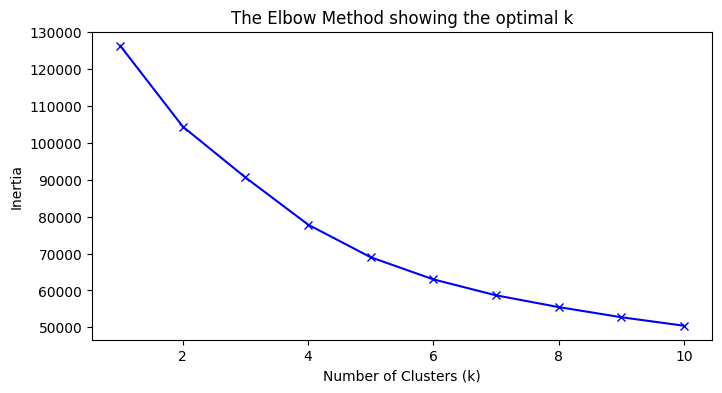

In [214]:
# ELBOW METHOD
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [215]:
# RUNNING K-MEANS 
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

In [216]:
# ANALYZE THE RESULTS
cluster_summary = df_final.groupby('cluster')[num_cols].mean()
print(cluster_summary)

         age_years   net_amount  transaction_count  return_rate_tx  \
cluster                                                              
0        49.029702  1362.633623          11.221817        0.029523   
1        49.112495   378.266852           3.195580        0.003294   
2        49.183352   387.434724           3.303197        0.005378   
3        48.742758   263.038033           7.700684        0.355469   

         nl_open_rate  nl_click_rate  recency_days  
cluster                                             
0            0.492237       0.156421     83.867358  
1            0.241284       0.037175    235.658599  
2            0.816452       0.339280    226.568495  
3            0.472471       0.146162    181.906365  


# DBSCAN

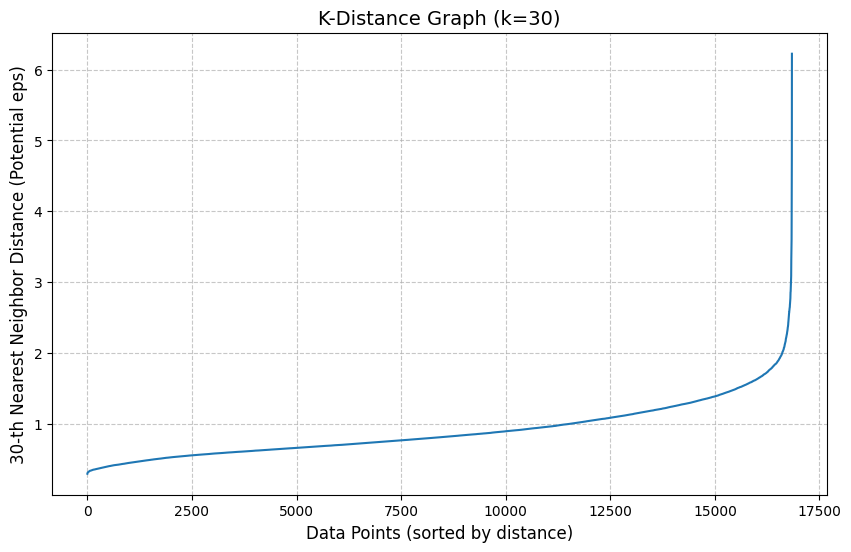

In [217]:
# Plot k-distance knee to find optimal epsilon (eps)
def plot_k_distance(data, k=30):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    
    distances, indices = neighbors_fit.kneighbors(data)

    k_distances = np.sort(distances[:, k-1], axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances)
    plt.title(f'K-Distance Graph (k={k})', fontsize=14)
    plt.xlabel('Data Points (sorted by distance)', fontsize=12)
    plt.ylabel(f'{k}-th Nearest Neighbor Distance (Potential eps)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_k_distance(X_scaled, k=30)

In [218]:
# INITIALIZE DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=30)

clusters_dbscan = dbscan.fit_predict(X_scaled)

df_final['cluster_dbscan'] = clusters_dbscan

n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_ = list(clusters_dbscan).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

dbscan_summary = df_final[df_final['cluster_dbscan'] != -1].groupby('cluster_dbscan')[num_cols].mean()
print("\n--- DBSCAN Cluster Averages ---")
print(dbscan_summary)

Estimated number of clusters: 1
Estimated number of noise points: 91

--- DBSCAN Cluster Averages ---
                age_years  net_amount  transaction_count  return_rate_tx  \
cluster_dbscan                                                             
0               49.078141  572.758026           5.357889        0.047768   

                nl_open_rate  nl_click_rate  recency_days  
cluster_dbscan                                             
0                   0.480361       0.157355     194.90323  


# OPTICS

In [219]:
# OPTICS will find the best epsilon for each cluster automatically
optics_model = OPTICS(min_samples=15, xi=0.05, min_cluster_size=0.05)
df_final['cluster_optics'] = optics_model.fit_predict(X_scaled)

print("--- OPTICS Cluster Sizes ---")
print(df_final['cluster_optics'].value_counts())

--- OPTICS Cluster Sizes ---
cluster_optics
0    16842
Name: count, dtype: int64


### Hairball problem, DBSCAN and OPTICS won't work as the data is a "Global Density" mass -> no clear gaps between customer groups. Need centroid-based or distribution-based clustering

# Gaussian Mixture Model

In [220]:
# 1. Initialize GMM
gmm = GaussianMixture(n_components=4, random_state=42)

df_final['cluster_gmm'] = gmm.fit_predict(X_scaled)

gmm_summary = df_final.groupby('cluster_gmm')[num_cols].mean().round(2)
print("--- GMM Cluster Averages ---")
print(gmm_summary)

--- GMM Cluster Averages ---
             age_years  net_amount  transaction_count  return_rate_tx  \
cluster_gmm                                                             
0                49.26      367.52               2.91            0.00   
1                49.09      589.89               4.72            0.00   
2                48.85     1060.82              13.21            0.20   
3                48.85      292.22               6.26            0.33   

             nl_open_rate  nl_click_rate  recency_days  
cluster_gmm                                             
0                    0.00           0.00        256.36  
1                    0.61           0.20        193.09  
2                    0.47           0.15         73.13  
3                    0.50           0.17        236.37  


In [221]:
# cluster sizes
print("--- Raw Cluster Sizes ---")
print(df_final['cluster_gmm'].value_counts())

print("\n--- Percentage Breakdown ---")
print(df_final['cluster_gmm'].value_counts(normalize=True) * 100)

--- Raw Cluster Sizes ---
cluster_gmm
1    10833
0     2822
2     1752
3     1435
Name: count, dtype: int64

--- Percentage Breakdown ---
cluster_gmm
1    64.321340
0    16.755730
2    10.402565
3     8.520366
Name: proportion, dtype: float64


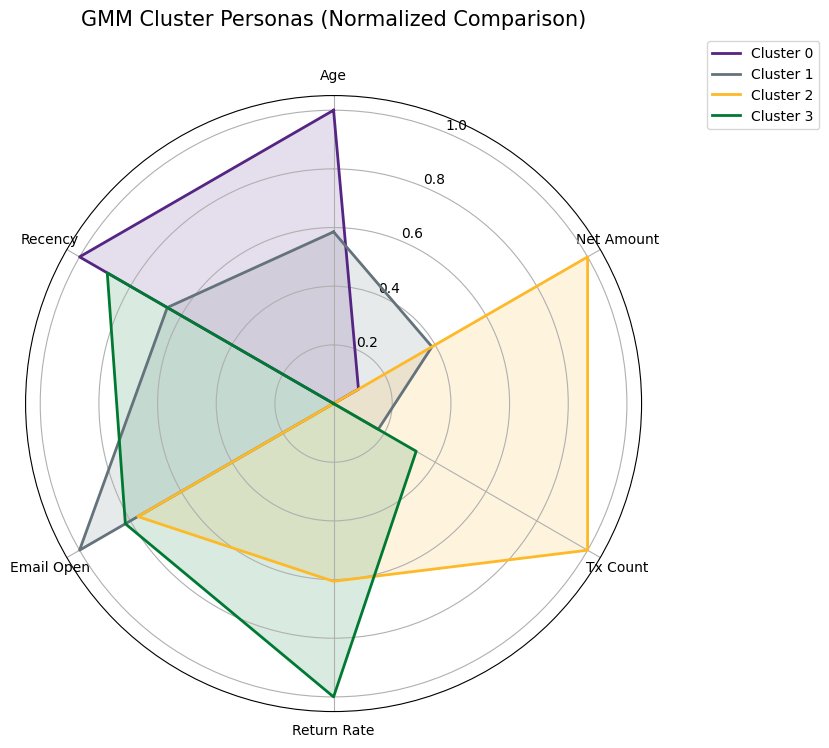

In [222]:
# Radar chart for GMM
labels = ['Age', 'Net Amount', 'Tx Count', 'Return Rate', 'Email Open', 'Recency']
stats = gmm_summary[['age_years', 'net_amount', 'transaction_count', 'return_rate_tx', 'nl_open_rate', 'recency_days']]

stats_norm = (stats - stats.min()) / (stats.max() - stats.min())

data_array = stats_norm.values 

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

data_plot = np.concatenate((data_array, data_array[:, [0]]), axis=1)
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#552583', '#63727b', '#fdb927', '#007a33'] 

for i in range(len(data_plot)):
    ax.plot(angles_plot, data_plot[i], color=colors[i], linewidth=2, label=f'Cluster {i}')
    ax.fill(angles_plot, data_plot[i], color=colors[i], alpha=0.15)

ax.set_thetagrids(np.degrees(angles), labels)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.title('GMM Cluster Personas (Normalized Comparison)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

# Hierarchical clustering

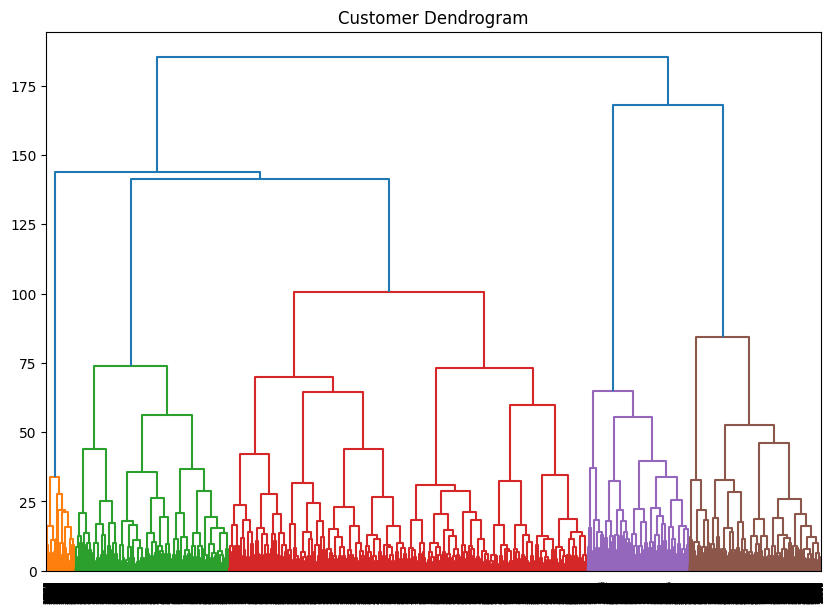

--- Hierarchical Clustering Averages ---
            age_years  net_amount  transaction_count  return_rate_tx  \
cluster_hc                                                             
0               49.82      490.72               4.13            0.00   
1               47.21     1434.14              11.24            0.02   
2               48.45      334.76               8.31            0.33   
3               49.20      364.76               3.16            0.02   
4               49.30      242.70               2.05            0.00   

            nl_open_rate  nl_click_rate  recency_days  
cluster_hc                                             
0                   0.48           0.14        116.29  
1                   0.47           0.14        110.72  
2                   0.47           0.14        172.03  
3                   1.00           1.00        249.75  
4                   0.42           0.07        454.83  

--- Cluster Sizes ---
cluster_hc
0    7795
1    2856
2    220

In [229]:
# VISUALIZE THE DENDROGRAM
plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.show()

# RUN THE CLUSTERING
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df_final['cluster_hc'] = hc.fit_predict(X_scaled)

hc_summary = df_final.groupby('cluster_hc')[num_cols].mean().round(2)
print("--- Hierarchical Clustering Averages ---")
print(hc_summary)

print("\n--- Cluster Sizes ---")
print(df_final['cluster_hc'].value_counts().sort_index())

In [224]:
# See which provinces have the most VIPs (Cluster 1)
vip_provinces = df_final[df_final['cluster_hc'] == 1]['province'].value_counts().head(10)
print("Top 10 Provinces for VIPs:\n", vip_provinces)

Top 10 Provinces for VIPs:
 province
Roma       192
Napoli     142
Milano     134
Torino     122
Palermo     68
Firenze     60
Bari        59
Verona      58
Brescia     58
Caserta     58
Name: count, dtype: int64


In [228]:
# Find provinces with a high number of VIPs RELATIVE to the national average
total_vips = len(df_final[df_final['cluster_hc'] == 1])
total_customers = len(df_final)
global_vip_rate = total_vips / total_customers

province_stats = df_final.groupby('province').agg(
    total_in_province=('customer_id', 'count'),
    vips_in_province=('cluster_hc', lambda x: (x == 1).sum())
)

# Filter out provinces with very few customers to avoid statistical "noise"
min_sample_size = 50 
province_stats = province_stats[province_stats['total_in_province'] >= min_sample_size].copy()

province_stats['actual_vip_rate'] = province_stats['vips_in_province'] / province_stats['total_in_province']
province_stats['vip_index'] = (((province_stats['actual_vip_rate'] / global_vip_rate) * 100)).round(1)

top_hotspots = province_stats.sort_values('vip_index', ascending=False).head(10)

print(f"Global VIP Baseline: {global_vip_rate:.2%}")
print("\n--- Top 10 Over-Performing Provinces (Hot Spots) ---")
print(top_hotspots[['total_in_province', 'vips_in_province', 'vip_index']])

Global VIP Baseline: 16.96%

--- Top 10 Over-Performing Provinces (Hot Spots) ---
                       total_in_province  vips_in_province  vip_index
province                                                             
Cagliari                             170                44      152.6
Barletta-Andria-Trani                100                25      147.4
Imperia                               50                12      141.5
Savona                                92                22      141.0
Oristano                              55                13      139.4
Catanzaro                            102                23      133.0
Pistoia                               80                18      132.7
Ragusa                                89                20      132.5
Brindisi                             125                27      127.4
Lodi                                  84                18      126.4
